In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, shutil, json, textwrap, sys

DRIVE_ROOT = "/content/drive/MyDrive"
PROJECT_ROOT = f"{DRIVE_ROOT}/svg_llm_competition"
DATA_DIR = f"{PROJECT_ROOT}/data"
ARTIFACTS_DIR = f"{PROJECT_ROOT}/artifacts"
SRC_DIR = f"{PROJECT_ROOT}/src"
CFG_DIR = f"{PROJECT_ROOT}/configs"

for p in [PROJECT_ROOT, DATA_DIR, ARTIFACTS_DIR, SRC_DIR, CFG_DIR]:
    Path(p).mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR =", DATA_DIR)
print("ARTIFACTS_DIR =", ARTIFACTS_DIR)


Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/svg_llm_competition
DATA_DIR = /content/drive/MyDrive/svg_llm_competition/data
ARTIFACTS_DIR = /content/drive/MyDrive/svg_llm_competition/artifacts


In [ ]:
from pathlib import Path
raw_dir = Path(DATA_DIR) / "raw"
required = ["train.csv", "test.csv", "sample_submission.csv"]
missing = [x for x in required if not (raw_dir / x).exists()]
print("raw_dir =", raw_dir)
print("files   =", sorted([p.name for p in raw_dir.glob("*")]))
assert not missing, f"Missing files: {missing}"


raw_dir = /content/drive/MyDrive/svg_llm_competition/data/raw
files   = ['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
!pip install -q \
transformers \
datasets \
accelerate \
peft \
bitsandbytes \
sentencepiece \
faiss-cpu \
pandas \
numpy \
scikit-learn \
tqdm \
lxml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 97.5 MB/s eta 0:00:00


In [ ]:
%cd $PROJECT_ROOT
!python /content/drive/MyDrive/svg_llm_competition/src/data_prep.py \
  --train_csv /content/drive/MyDrive/svg_llm_competition/data/raw/train.csv \
  --test_csv /content/drive/MyDrive/svg_llm_competition/data/raw/test.csv \
  --out_dir /content/drive/MyDrive/svg_llm_competition/data/processed \
  --n_folds 5


/content/drive/MyDrive/svg_llm_competition
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
saved: /content/drive/MyDrive/svg_llm_competition/data/processed
           svg_len     num_paths
count  50000.00000  50000.000000
mean    2510.23876      2.420100
std     1768.55902      3.427304
min       86.00000      0.000000
25%     1112.00000      1.000000
50%     2098.00000      1.000000
75%     3514.00000      3.000000
max    15937.00000    303.000000


In [ ]:
%cd $PROJECT_ROOT
!python src/build_retrieval_index.py   --train_csv "$DATA_DIR/processed/train_prepared.csv"   --out_dir "$ARTIFACTS_DIR/retrieval"

/content/drive/MyDrive/svg_llm_competition
modules.json: 100% 349/349 [00:00<00:00, 2.23MB/s]
config_sentence_transformers.json: 100% 116/116 [00:00<00:00, 778kB/s]
README.md: 10.5kB [00:00, 33.6MB/s]
sentence_bert_config.json: 100% 53.0/53.0 [00:00<00:00, 408kB/s]
config.json: 100% 612/612 [00:00<00:00, 3.71MB/s]
model.safetensors: 100% 90.9M/90.9M [00:01<00:00, 54.3MB/s]
Loading weights: 100% 103/103 [00:00<00:00, 1464.76it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
tokenizer_config.json: 100% 350/350 [00:00<00:00, 2.56MB/s]
vocab.txt: 232kB [00:00, 77.7MB/s]
tokenizer.json: 466kB [00:00, 113MB/s]
special_tokens_map.json: 100% 112/112 [00:00<00:00, 862kB/s]
config.json: 1

In [ ]:
!pip install -q \
trl \
transformers \
accelerate \
datasets \
peft \
bitsandbytes \
sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 37.1 MB/s eta 0:00:00


In [ ]:
import yaml
from pathlib import Path
import torch

ROOT = "/content/drive/MyDrive/svg_llm_competition"
CFG_PATH = Path(f"{ROOT}/configs/base.yaml")

with open(CFG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

cfg["project_root"] = ROOT
cfg["data_dir"] = f"{ROOT}/data"
cfg["artifacts_dir"] = f"{ROOT}/artifacts"
cfg["retrieval_dir"] = f"{ROOT}/artifacts/retrieval"
cfg["train_csv"] = f"{ROOT}/data/processed/train_clean.csv"
cfg["test_csv"] = f"{ROOT}/data/processed/test_clean.csv"
cfg["folds_csv"] = f"{ROOT}/data/processed/folds.csv"
cfg["output_root"] = f"{ROOT}/artifacts/models"

cfg["base_model"] = "Qwen/Qwen2.5-3B-Instruct"
cfg["model_name"] = "Qwen/Qwen2.5-3B-Instruct"
cfg["load_in_4bit"] = True
cfg["bf16"] = True
cfg["fp16"] = False

cfg["max_length"] = 3072
cfg["max_seq_len"] = 3072

cfg["learning_rate"] = 2e-4
cfg["weight_decay"] = 0.01
cfg["warmup_ratio"] = 0.03

cfg["per_device_train_batch_size"] = 1
cfg["per_device_eval_batch_size"] = 1
cfg["gradient_accumulation_steps"] = 16
cfg["num_train_epochs"] = 2

cfg["lora_r"] = 64
cfg["lora_alpha"] = 128
cfg["lora_dropout"] = 0.05

cfg["logging_steps"] = 25
cfg["eval_steps"] = 500
cfg["save_steps"] = 500
cfg["dataloader_num_workers"] = 4
cfg["dataloader_pin_memory"] = True

with open(CFG_PATH, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

print("Fixed config:\n")
print(yaml.safe_dump(cfg, sort_keys=False))

torch.set_float32_matmul_precision("high")

print("\nStarting training...\n")
!python {ROOT}/src/train_sft.py \
  --config {CFG_PATH} \
  --run_name seed11

Streaming output truncated to the last 5000 lines.
 50% 5006/10000 [14:58<14:50,  5.61it/s]
 50% 5007/10000 [14:58<14:50,  5.61it/s]
 50% 5008/10000 [14:58<14:51,  5.60it/s]
 50% 5009/10000 [14:58<14:51,  5.60it/s]
 50% 5010/10000 [14:59<14:49,  5.61it/s]
 50% 5011/10000 [14:59<14:46,  5.62it/s]
 50% 5012/10000 [14:59<14:48,  5.62it/s]
 50% 5013/10000 [14:59<14:49,  5.61it/s]
 50% 5014/10000 [14:59<14:49,  5.60it/s]
 50% 5015/10000 [14:59<14:50,  5.60it/s]
 50% 5016/10000 [15:00<14:55,  5.57it/s]
 50% 5017/10000 [15:00<14:56,  5.56it/s]
 50% 5018/10000 [15:00<14:55,  5.57it/s]
 50% 5019/10000 [15:00<14:53,  5.57it/s]
 50% 5020/10000 [15:00<14:54,  5.57it/s]
 50% 5021/10000 [15:01<14:53,  5.57it/s]
 50% 5022/10000 [15:01<14:53,  5.57it/s]
 50% 5023/10000 [15:01<14:51,  5.58it/s]
 50% 5024/10000 [15:01<14:52,  5.57it/s]
 50% 5025/10000 [15:01<14:51,  5.58it/s]
 50% 5026/10000 [15:01<14:53,  5.57it/s]
 50% 5027/10000 [15:02<14:52,  5.57it/s]
 50% 5028/10000 [15:02<14:56,  5.55it/s]
 50% 5

In [ ]:
pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.5 MB/s eta 0:00:00


In [2]:
import yaml
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/svg_llm_competition")
CFG_PATH = PROJECT_ROOT / "configs" / "base.yaml"

with open(CFG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

cfg["candidate_temps"] = [0.4]
cfg["candidate_top_ps"] = [0.9]
cfg["max_new_tokens"] = 400
cfg["generation_max_new_tokens"] = 400
cfg["retrieval_k"] = 0
cfg["retrieval_top_k"] = 0

with open(CFG_PATH, "w") as f:
    yaml.safe_dump(cfg, f, sort_keys=False)

In [ ]:
PROJECT_ROOT = "/content/drive/MyDrive/svg_llm_competition"
CONFIG_PATH = f"{PROJECT_ROOT}/configs/base.yaml"
ADAPTER_DIR = f"{PROJECT_ROOT}/artifacts/models/seed11/final"
OUT_FILE = f"{PROJECT_ROOT}/artifacts/test_predictions_fast.csv"

print("Using adapter:", ADAPTER_DIR)
print("Saving predictions to:", OUT_FILE)

!python -u {PROJECT_ROOT}/src/generate_candidates.py \
  --mode test \
  --config {CONFIG_PATH} \
  --adapter_dir {ADAPTER_DIR} \
  --out_file {OUT_FILE}

Using adapter: /content/drive/MyDrive/svg_llm_competition/artifacts/models/seed11/final
Saving predictions to: /content/drive/MyDrive/svg_llm_competition/artifacts/test_predictions_fast.csv
LOADING TOKENIZER AND MODEL
Loading weights: 100% 434/434 [00:01<00:00, 277.32it/s, Materializing param=model.norm.weight]
RETRIEVAL DISABLED
Mode: test
Input file: /content/drive/MyDrive/svg_llm_competition/data/processed/test_clean.csv
Rows to process: 1000
Temperatures: [0.4]
Top-p values: [0.9]
Candidates per prompt: 1
Total generations: 1000
Max new tokens: 400
Adapter dir: /content/drive/MyDrive/svg_llm_competition/artifacts/models/seed11/final
Output file: /content/drive/MyDrive/svg_llm_competition/artifacts/test_predictions_fast.csv
Generating test SVGs: 100% 1000/1000 [10:07:49<00:00, 36.47s/it, cand=1/1, prompt=1000/1000, saved=1000]
Saved predictions to: /content/drive/MyDrive/svg_llm_competition/artifacts/test_predictions_fast.csv
Total rows saved: 1000


In [ ]:
import pandas as pd
from pathlib import Path
import re

PROJECT_ROOT = Path("/content/drive/MyDrive/svg_llm_competition")
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "test.csv"
PRED_PATH = PROJECT_ROOT / "artifacts" / "test_predictions_fast.csv"
OUT_PATH = PROJECT_ROOT / "submissions" / "submission_fast.csv"

test_df = pd.read_csv(TEST_PATH)
pred_df = pd.read_csv(PRED_PATH)

id_col = "id"
svg_col = "candidate_svg" if "candidate_svg" in pred_df.columns else "svg"

pred_df = pred_df[[id_col, svg_col]].rename(columns={svg_col: "svg"})

pred_df["svg_len_tmp"] = pred_df["svg"].astype(str).str.len()
pred_df = pred_df.sort_values(["id", "svg_len_tmp"]).drop_duplicates("id", keep="first")
pred_df = pred_df.drop(columns=["svg_len_tmp"])

EMPTY_SVG = '<svg width="256" height="256" viewBox="0 0 256 256"></svg>'

def sanitize_svg(x):
    if pd.isna(x):
        return EMPTY_SVG
    x = str(x).strip()
    if not x.startswith("<svg"):
        return EMPTY_SVG
    if len(x) > 16000:
        return EMPTY_SVG
    if len(re.findall(r"<path\\b", x)) > 256:
        return EMPTY_SVG
    return x

pred_df["svg"] = pred_df["svg"].map(sanitize_svg)

sub = test_df[["id"]].merge(pred_df, on="id", how="left")
sub["svg"] = sub["svg"].fillna(EMPTY_SVG)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
sub.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print(sub.head())
print("Rows:", len(sub))

Saved: /content/drive/MyDrive/svg_llm_competition/submissions/submission_fast.csv
                                     id  \
0  fa1d8fa7-080f-4269-a9cf-a17562c9a0ca   
1      6eede943219547c22ac56085027d33cc   
2      ea045c7a247166f061ce504d9b7ccaab   
3      8fe82f3af89e487b31236ca829c3f071   
4      600464e4d92c75338462271a09b3f176   

                                                 svg  
0  <svg xmlns="http://www.w3.org/2000/svg" height...  
1  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
2  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
3  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
4  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
Rows: 1000


In [ ]:
import pandas as pd
import re

sub = pd.read_csv("/content/drive/MyDrive/svg_llm_competition/submissions/submission_fast.csv")

print("Rows:", len(sub))
print("Columns:", sub.columns.tolist())
print("Missing SVGs:", sub["svg"].isna().sum())
print("Starts with <svg:", sub["svg"].astype(str).str.startswith("<svg").mean())
print("Too long:", (sub["svg"].astype(str).str.len() > 16000).sum())
print("Too many paths:", sub["svg"].astype(str).map(lambda s: len(re.findall(r"<path\\b", s))).gt(256).sum())
print(sub.head(3))

Rows: 1000
Columns: ['id', 'svg']
Missing SVGs: 0
Starts with <svg: 1.0
Too long: 0
Too many paths: 0
                                     id  \
0  fa1d8fa7-080f-4269-a9cf-a17562c9a0ca   
1      6eede943219547c22ac56085027d33cc   
2      ea045c7a247166f061ce504d9b7ccaab   

                                                 svg  
0  <svg xmlns="http://www.w3.org/2000/svg" height...  
1  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
2  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  


In [ ]:
done

Prompt:
The image features a black outline of a document or folder icon with a lock symbol, set against a white background.


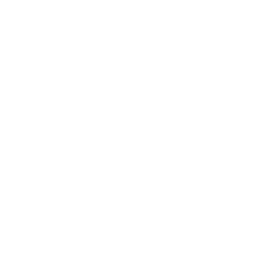

In [ ]:
import pandas as pd
from IPython.display import SVG, display

test = pd.read_csv("/content/drive/MyDrive/svg_llm_competition/data/raw/test.csv")
sub = pd.read_csv("/content/drive/MyDrive/svg_llm_competition/submissions/submission_fast.csv")

row = sub.sample(1).iloc[0]

prompt = test[test["id"] == row["id"]]["prompt"].values[0]

print("Prompt:")
print(prompt)

display(SVG(row["svg"]))